In [1]:
import uproot
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import awkward as ak
import numpy as np
import math
import ROOT as root
from array import array

Welcome to JupyROOT 6.26/16


In [2]:
#Trying to flesh out the relationship between hit segments and the trajectory points. 
#pull the edep-sim file we have
f = root.TFile.Open("/sdf/home/t/tanaka/MicroProdN4p1_NDComplex_FHC.spill.full.0002459.EDEPSIM_SPILLS.root")
events = f.Get("EDepSimEvents")

# Set the branch address.
event = root.TG4Event()
events.SetBranchAddress("Event",root.AddressOf(event))
keys_file = uproot.open("/sdf/home/t/tanaka/MicroProdN4p1_NDComplex_FHC.spill.full.0002459.EDEPSIM_SPILLS.root")


In [3]:
#literally just to have the convenient display haha
edep_sim_events = keys_file['EDepSimEvents']
edep_sim_events.keys()

['Event',
 'Event/TObject',
 'Event/TObject/fUniqueID',
 'Event/TObject/fBits',
 'Event/RunId',
 'Event/EventId',
 'Event/Primaries',
 'Event/Primaries/Primaries.fUniqueID',
 'Event/Primaries/Primaries.fBits',
 'Event/Primaries/Primaries.Particles',
 'Event/Primaries/Primaries.Informational',
 'Event/Primaries/Primaries.Position',
 'Event/Primaries/Primaries.GeneratorName',
 'Event/Primaries/Primaries.Reaction',
 'Event/Primaries/Primaries.Filename',
 'Event/Primaries/Primaries.InteractionNumber',
 'Event/Primaries/Primaries.CrossSection',
 'Event/Primaries/Primaries.DiffCrossSection',
 'Event/Primaries/Primaries.Weight',
 'Event/Primaries/Primaries.Probability',
 'Event/Trajectories',
 'Event/Trajectories/Trajectories.fUniqueID',
 'Event/Trajectories/Trajectories.fBits',
 'Event/Trajectories/Trajectories.Points',
 'Event/Trajectories/Trajectories.TrackId',
 'Event/Trajectories/Trajectories.ParentId',
 'Event/Trajectories/Trajectories.Name',
 'Event/Trajectories/Trajectories.PDGCode',


In [4]:
#grab the event, from here we can draw hit segments or our trajectory points
events.GetEntry(2)
tms_hit_segments = event.SegmentDetectors['volTMS']
print(tms_hit_segments.size())
event_trajectories = event.Trajectories 
event_trajectories.size()

138


69

In [8]:
hit_segment_xs = []
hit_segment_zs = []
hit_segment_ts = []

traj_point_xs = []
traj_point_zs = []
traj_point_ts = []
for hit_segment in tms_hit_segments:
    hit_segment_id = (hit_segment.Contrib[0]) #the track id of what caused the hit!
    x = (hit_segment.GetStop()[0] + hit_segment.GetStart()[0]) / 2
    z = (hit_segment.GetStop()[2] + hit_segment.GetStart()[2]) / 2
    t = (hit_segment.GetStop()[3] + hit_segment.GetStart()[3]) / 2
    hit_segment_xs.append(x)
    hit_segment_zs.append(z)
    hit_segment_ts.append(t)
    for traj_vector in event_trajectories:
        if traj_vector.GetTrackId() == hit_segment_id:
            #print(traj_vector.GetPDGCode()) #we can get the pdgid information from the vector, not the positions tho, need particles
            traj_points = traj_vector.Points
            xpoints = []
            zpoints = []
            tpoints = []
            for point in traj_points:
                #print(point.GetProcess())
                traj_point_xs.append(point.GetPosition()[0])
                traj_point_zs.append(point.GetPosition()[2])
                traj_point_ts.append(point.GetPosition()[3])

    

In [19]:
events.GetEntry(0)
tms_hit_segments = event.SegmentDetectors['volTMS']
print(f"Found {tms_hit_segments.size()} Hit Segments")
event_trajectories = event.Trajectories 
event_trajectories.size()

hit_segment_xs = []
hit_segment_ys = []
hit_segment_zs = []
hit_segment_ts = []

traj_point_xs = []
traj_point_zs = []
traj_point_ts = []
#let's take a look at a very specific case, just a muon!
for hit_segment in tms_hit_segments:
    hit_segment_id = (hit_segment.Contrib[0]) #the track id of what caused the hit!
    x = (hit_segment.GetStop()[0] + hit_segment.GetStart()[0]) / 2
    y = (hit_segment.GetStop()[1] + hit_segment.GetStart()[1]) / 2
    z = (hit_segment.GetStop()[2] + hit_segment.GetStart()[2]) / 2
    t = (hit_segment.GetStop()[3] + hit_segment.GetStart()[3]) / 2
    hit_segment_xs.append(x)
    hit_segment_ys.append(y)
    hit_segment_zs.append(z)
    hit_segment_ts.append(t)
    for traj_vector in event_trajectories:
        if traj_vector.GetTrackId() == hit_segment_id: #only select for the muon trackids
            print(f"{hit_segment_id} - {traj_vector.GetPDGCode()}")
            points = traj_vector.Points
            for point in points:
                print(point.GetSubprocess())

Found 7 Hit Segments
42 - 11
13
2
2
2
22
42 - 11
13
2
2
2
22
42 - 11
13
2
2
2
22
42 - 11
13
2
2
2
22
42 - 11
13
2
2
2
22
42 - 11
13
2
2
2
22
43 - 11
2
22


Text(0.5, 0, 'y-axis')

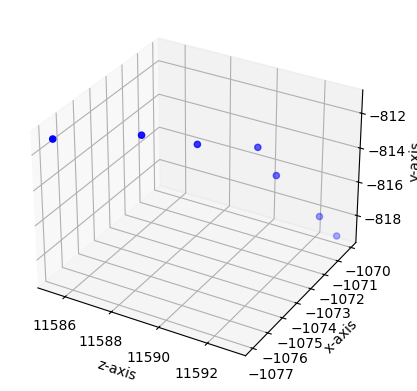

In [20]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(hit_segment_zs, hit_segment_xs, hit_segment_ys, c='blue', marker='o')

ax.set_xlabel('z-axis')
ax.set_ylabel('x-axis')
ax.set_zlabel('y-axis')